# Week 2 Lab: Implement and explore a Variational Autoencoder (VAE)

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, 3, 4

You will implement a VAE in **PyTorch**, train it on handwritten digits (MNIST), and use it to:

1. visualise its **latent space** and decode a grid of latent points,
2. **interpolate** between two digits,
3. study the effect of the KL weight **β**,
4. detect **unusual inputs** with reconstruction error,
5. (extension) build a **conditional VAE** that draws the digit you ask for.

| Part | Topic | Suggested time |
|---|---|---|
| 0 | Setup and data | 10 min |
| 1 | Build the VAE | 25 min |
| 2 | Train and monitor | 15 min |
| 3 | Explore the latent space | 25 min |
| 4 | The β trade-off | 20 min |
| 5 | Anomaly detection | 15 min |
| 6 | Extension: conditional VAE | optional |

> **INSTRUCTOR VERSION — contains solutions. Do not distribute before the lab.**

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **GPU** if available. A T4 is sufficient for the GPU examples. Free GPU access varies. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. Read this week's runtime note. Model downloads and training can take longer on CPU, and some full experiments need a GPU.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete before running dependent cells. Questions marked ✍️ need a short written answer.
> - Read each diagram by following its numbered blocks. The solid arrows carry data to the next block. A dashed arrow shows a step that repeats.

## This week's place in the course

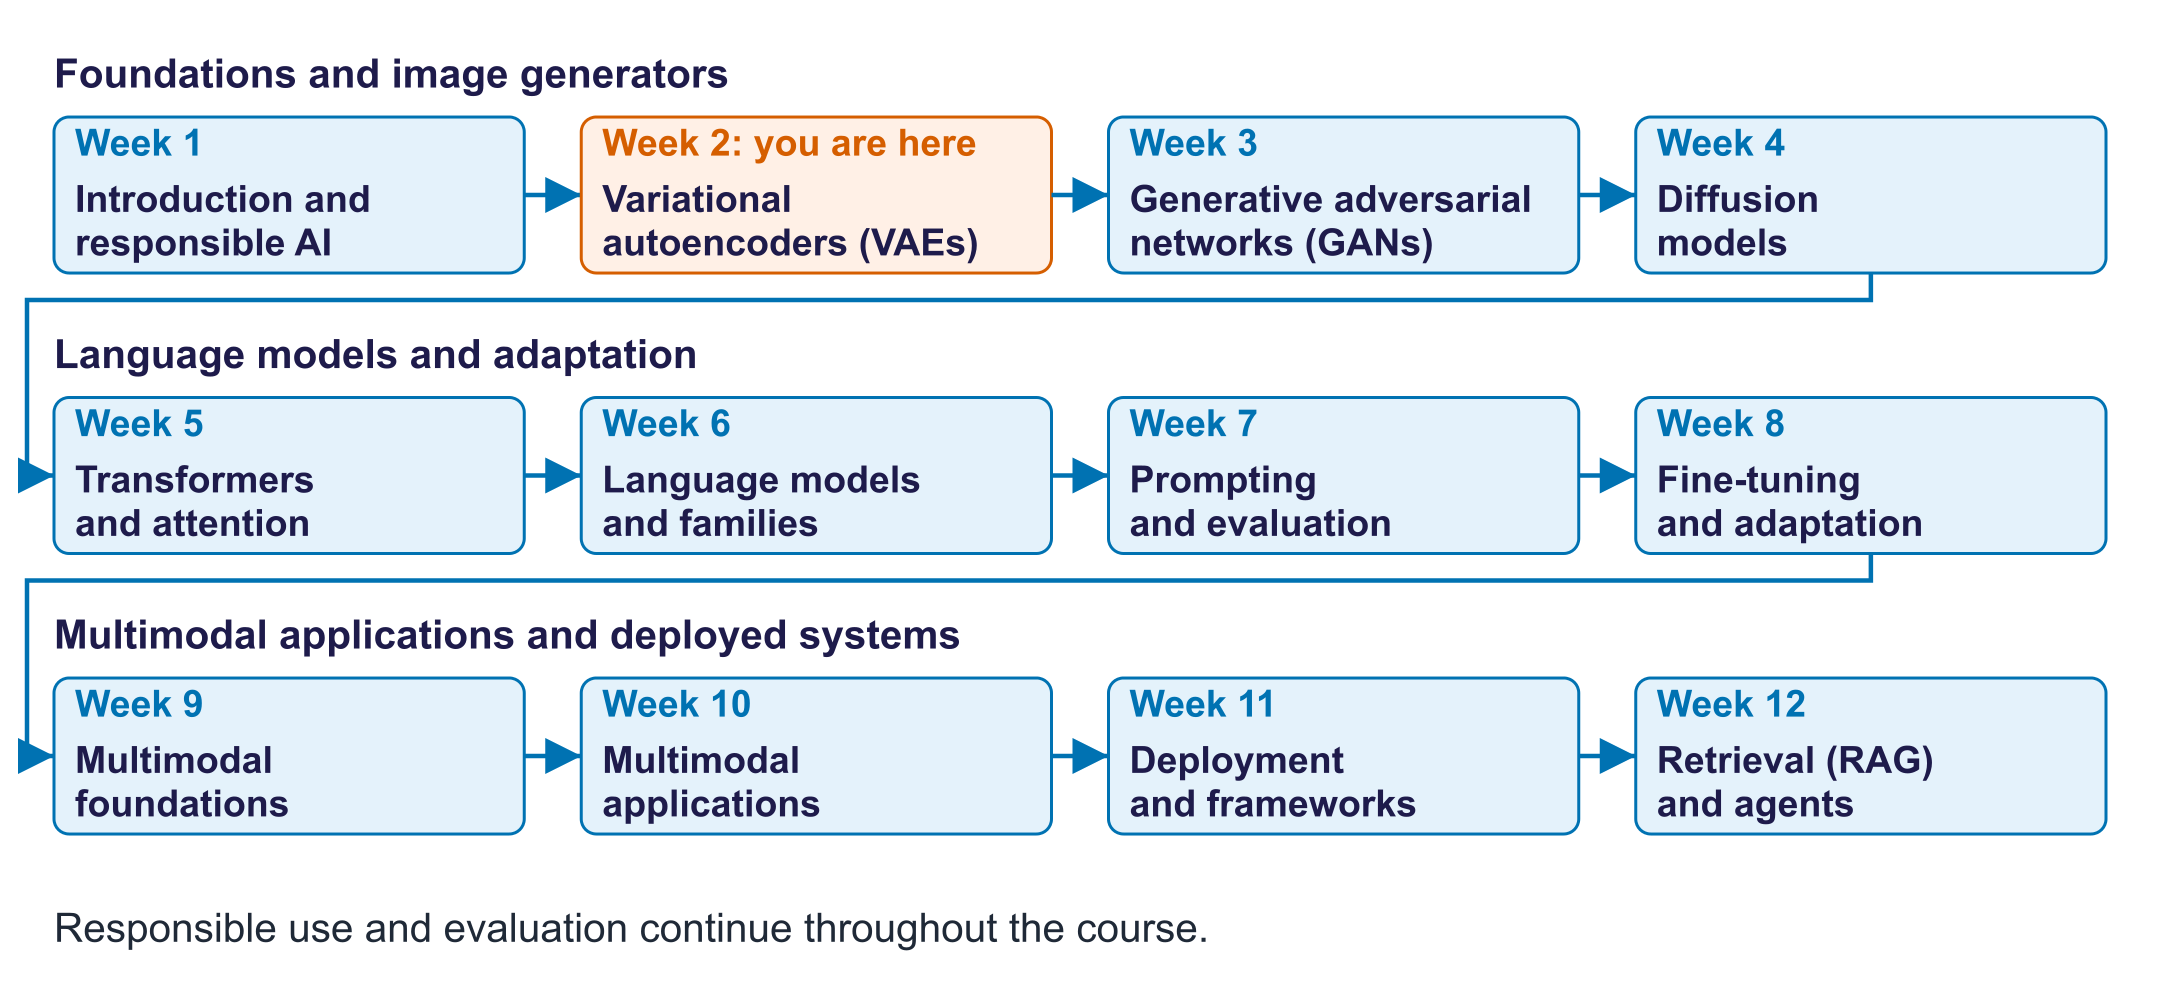

## Before coding: two paths through the VAE

**Reconstruction** starts with an image and asks the model to rebuild it.
**Generation** starts with a new random latent code and uses the trained
decoder. A latent code is a short numerical representation, not a digit label.

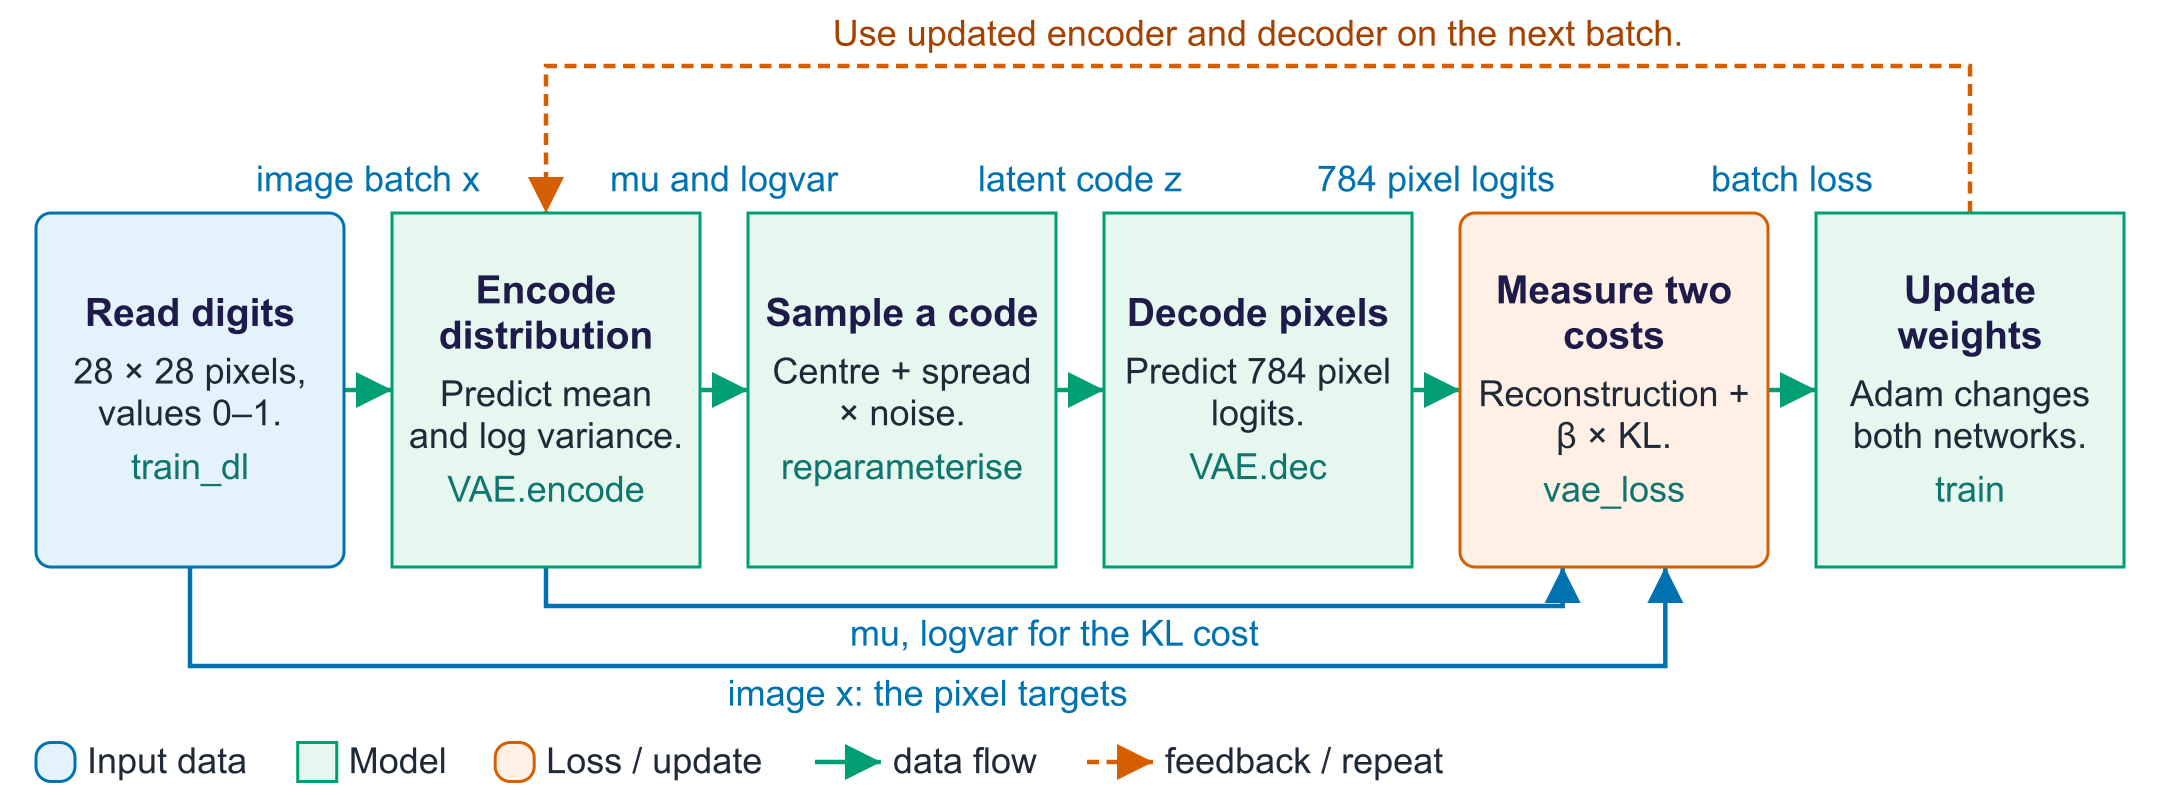

Follow `train_dl` → `VAE.encode` → `VAE.reparameterise` → `VAE.dec` →
`vae_loss` → `train`. The encoder branches into `mu` and `logvar`, and both
feed the sampled code. The original image also enters the reconstruction cost;
`mu` and `logvar` enter the KL cost directly. Weight updates repeat this path.

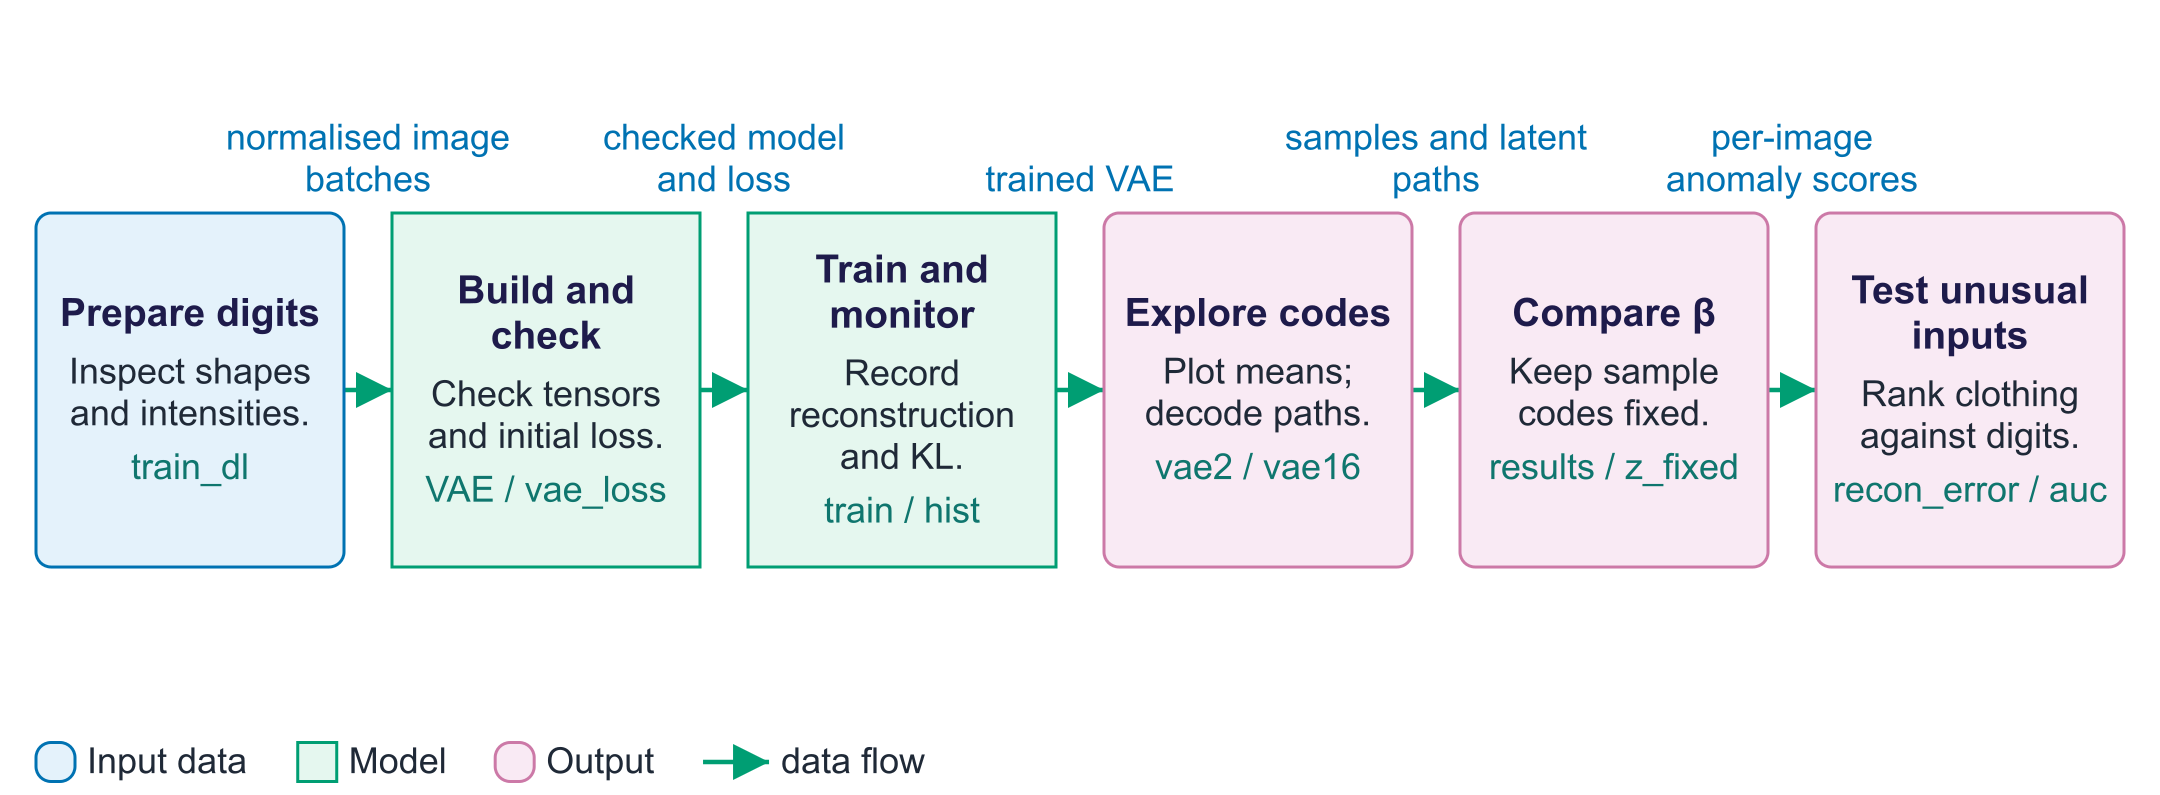

| Diagram block | Code to find | First observation |
|---|---|---|
| Prepare digits | `train_dl`, `x_test` | Each image is `[1, 28, 28]`; one image contains 784 pixels. |
| Build and check | `VAE`, `vae_loss` | The encoder has two outputs; the decoder returns pixel logits. |
| Train and monitor | `train`, `hist` | Reconstruction and KL are recorded separately. |
| Explore codes | `vae2`, `vae16`, `interpolate` | A code can come from an image or from the prior. |
| Compare beta | `results`, `z_fixed` | Separate models decode the same fixed codes. |
| Check unusual inputs | `recon_error`, `auc` | There is one reconstruction score per test image. |

**Pause and predict:** when generating from a fresh prior code, which blocks
can be bypassed? Trace the input path before looking at the sample grid.

## Part 0 · Setup and data

**Read:** a VAE learns a short code for an image, then rebuilds the image
from that code. A **batch** is a group of examples processed together; `B`
is its size. An **epoch** is one pass through the training dataset.
**Run:** complete the model and loss TODOs, then run the untrained check
before the training loop. That check catches wiring errors early.
**Change:** compare `zdim=2` with `zdim=16`, then compare the beta settings.
**Check:** record reconstruction and KL separately; a smaller total loss
with a different beta is not a fair comparison by itself.

**Purpose:** Install image and model libraries.
**Why now:** The notebook needs torchvision and PyTorch.
**Expected observation:** Package installation completes or reports an environment error.

In [ ]:
%pip install -q torch torchvision scikit-learn matplotlib

**Purpose:** Load and inspect MNIST.
**Why now:** Pixels and batch shape give the model’s input contract.
**Expected observation:** Images have one channel and 784 intensities.

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
torch.manual_seed(0)
np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 1 if SMOKE else 10
print("device:", DEVICE, "| epochs:", EPOCHS)

tf = transforms.ToTensor()  # pixels in [0, 1]
train_set = datasets.MNIST("data", train=True, download=True, transform=tf)
test_set = datasets.MNIST("data", train=False, download=True, transform=tf)
if SMOKE:
    train_set = Subset(train_set, range(3000))
train_dl = DataLoader(train_set, batch_size=128, shuffle=True)
x_test, y_test = next(iter(DataLoader(Subset(test_set, range(5000)), batch_size=5000)))
print("train images:", len(train_set), "| image shape:", tuple(x_test.shape[1:]))

plt.figure(figsize=(8, 1.2))
plt.imshow(np.hstack(x_test[:12, 0].numpy()), cmap="gray_r")
plt.axis("off")
plt.title("Some MNIST test digits")
plt.show()

## Part 1 · Build the VAE

The encoder outputs the **mean** μ and **log-variance** log σ² of a Gaussian over the code z. The decoder turns z into 784 pixel **logits**.

**TODO 1:** in `encode`, compute `mu` and `logvar` from the hidden layer.
**TODO 2:** implement the **reparameterisation trick**: $z = \mu + \sigma \odot \epsilon$ with $\epsilon \sim \mathcal{N}(0, I)$ and $\sigma = \exp(\tfrac12 \log\sigma^2)$.

**Read the shapes:** for a batch of `B` images and latent size `zdim`, the
two encoder outputs both have shape `[B, zdim]`. `logvar` is a log-variance,
not a standard deviation. `forward` returns `[B, 784]` pixel logits plus both
encoder outputs, allowing the two loss terms to take different input paths.

Read the sampling formula as "centre + spread × fresh random noise".
`mu` is the centre, `std` is the spread, and `eps` supplies random variation.
`N(0, I)` means independent bell-shaped noise values with mean 0 and
variance 1. The symbol `⊙` means multiply matching entries, not a matrix product.
A **logit** is a raw pixel score; sigmoid turns it into a value from 0 to 1.

**Purpose:** Implement the VAE’s two paths.
**Why now:** Encoding an image differs from drawing a prior code.
**Expected observation:** mu/logvar have latent-size shape; decoder logits have 784 entries.

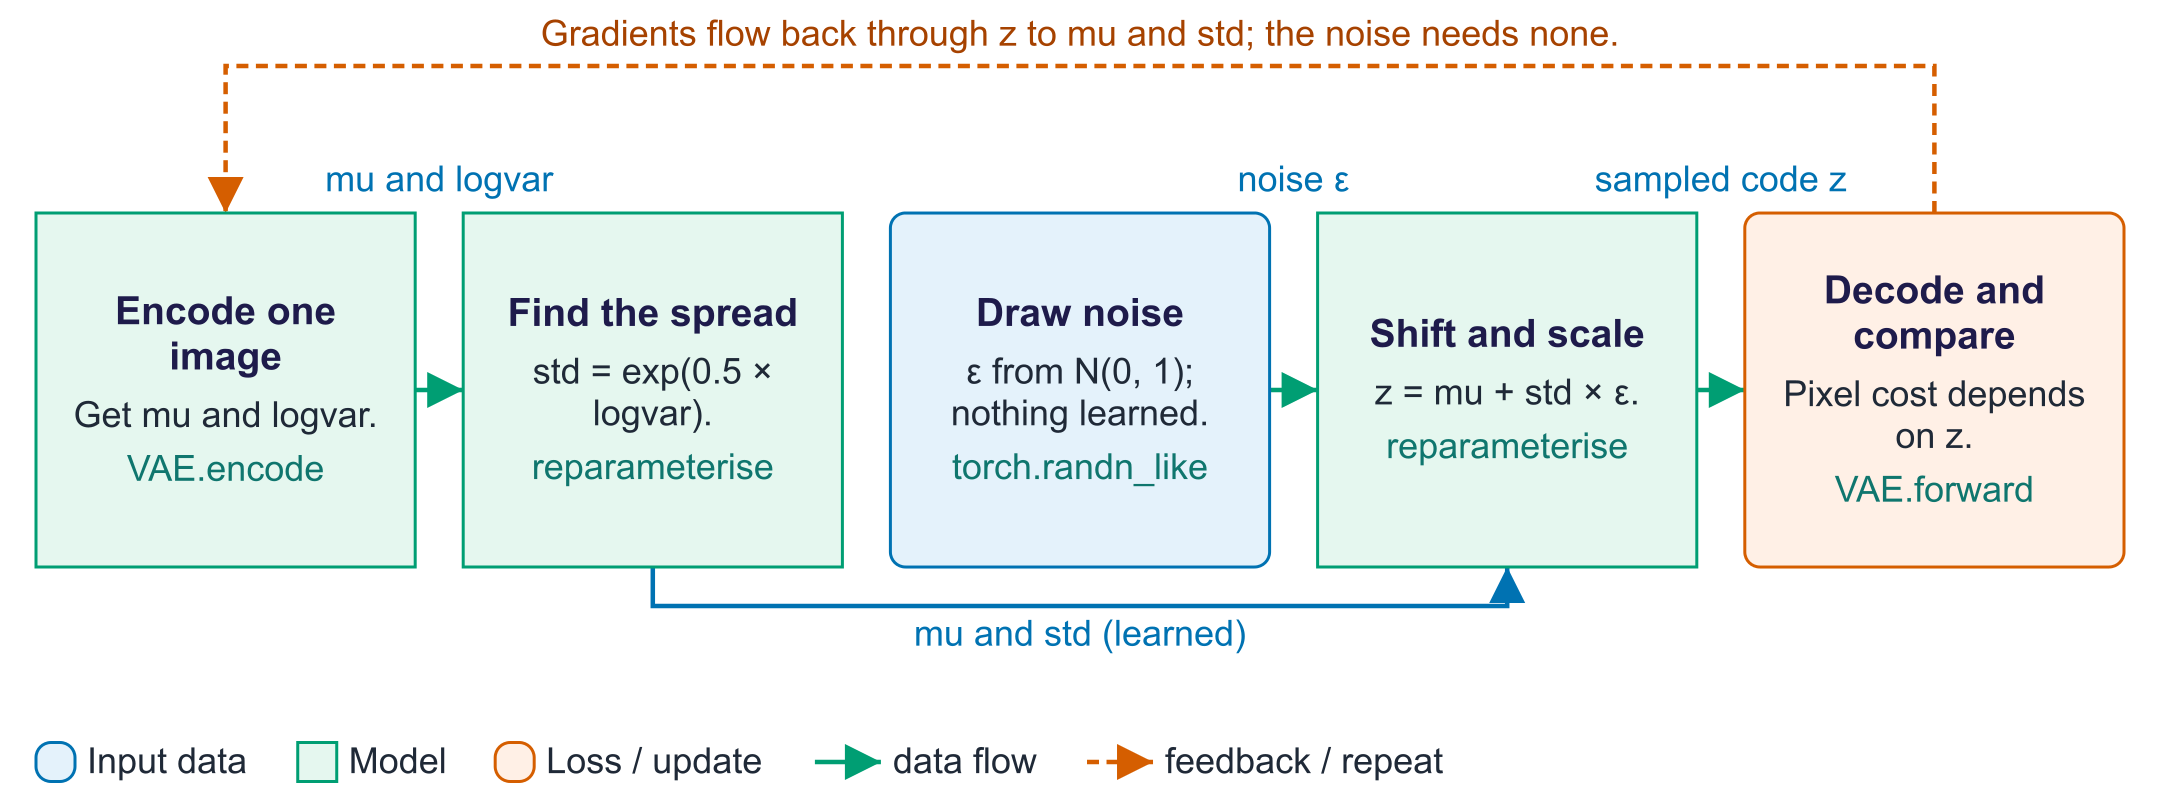

In [ ]:
class VAE(nn.Module):
    def __init__(self, zdim=2, hidden=400):
        super().__init__()
        self.zdim = zdim
        self.enc = nn.Sequential(nn.Flatten(), nn.Linear(784, hidden), nn.ReLU())
        self.mu_head = nn.Linear(hidden, zdim)
        self.logvar_head = nn.Linear(hidden, zdim)
        self.dec = nn.Sequential(nn.Linear(zdim, hidden), nn.ReLU(), nn.Linear(hidden, 784))

    def encode(self, x):
        h = self.enc(x)
        mu, logvar = self.mu_head(h), self.logvar_head(h)
        return mu, logvar

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.dec(z), mu, logvar

    @torch.no_grad()
    def decode(self, z):
        # Display pixel probabilities; this path needs a code, not an input image.
        return torch.sigmoid(self.dec(z)).view(-1, 28, 28)

**TODO 3:** implement the **negative ELBO** (per image):

* reconstruction: binary cross-entropy **summed over pixels** (use `F.binary_cross_entropy_with_logits`),
* KL: $\tfrac12\sum_j(\mu_j^2 + \sigma_j^2 - \log\sigma_j^2 - 1)$,
* total = reconstruction + β · KL, all divided by the batch size.
At β = 1 this is the standard VAE objective. For binary targets it is the literal negative ELBO; greyscale targets use a soft-target BCE surrogate. Other β values reweight KL.
Summing over pixels answers "how costly is one whole image?"; averaging
over the batch lets batches of different sizes use a comparable scale.

**In plain language:** the reconstruction term asks "did we rebuild the
input pixels?" The KL term asks "how far is this image's code distribution
from the standard random-code distribution?" Beta controls the weight of
that second question. **ELBO** is the training bound these terms come from.
The subscript `j` selects one latent coordinate; the sum adds its cost across
all coordinates. We optimise the negative bound, so lower is better.

**Purpose:** Implement and check both costs.
**Why now:** Training requires gradients from reconstruction and KL.
**Expected observation:** An untrained pixel cost near 784 × ln 2; finite KL.

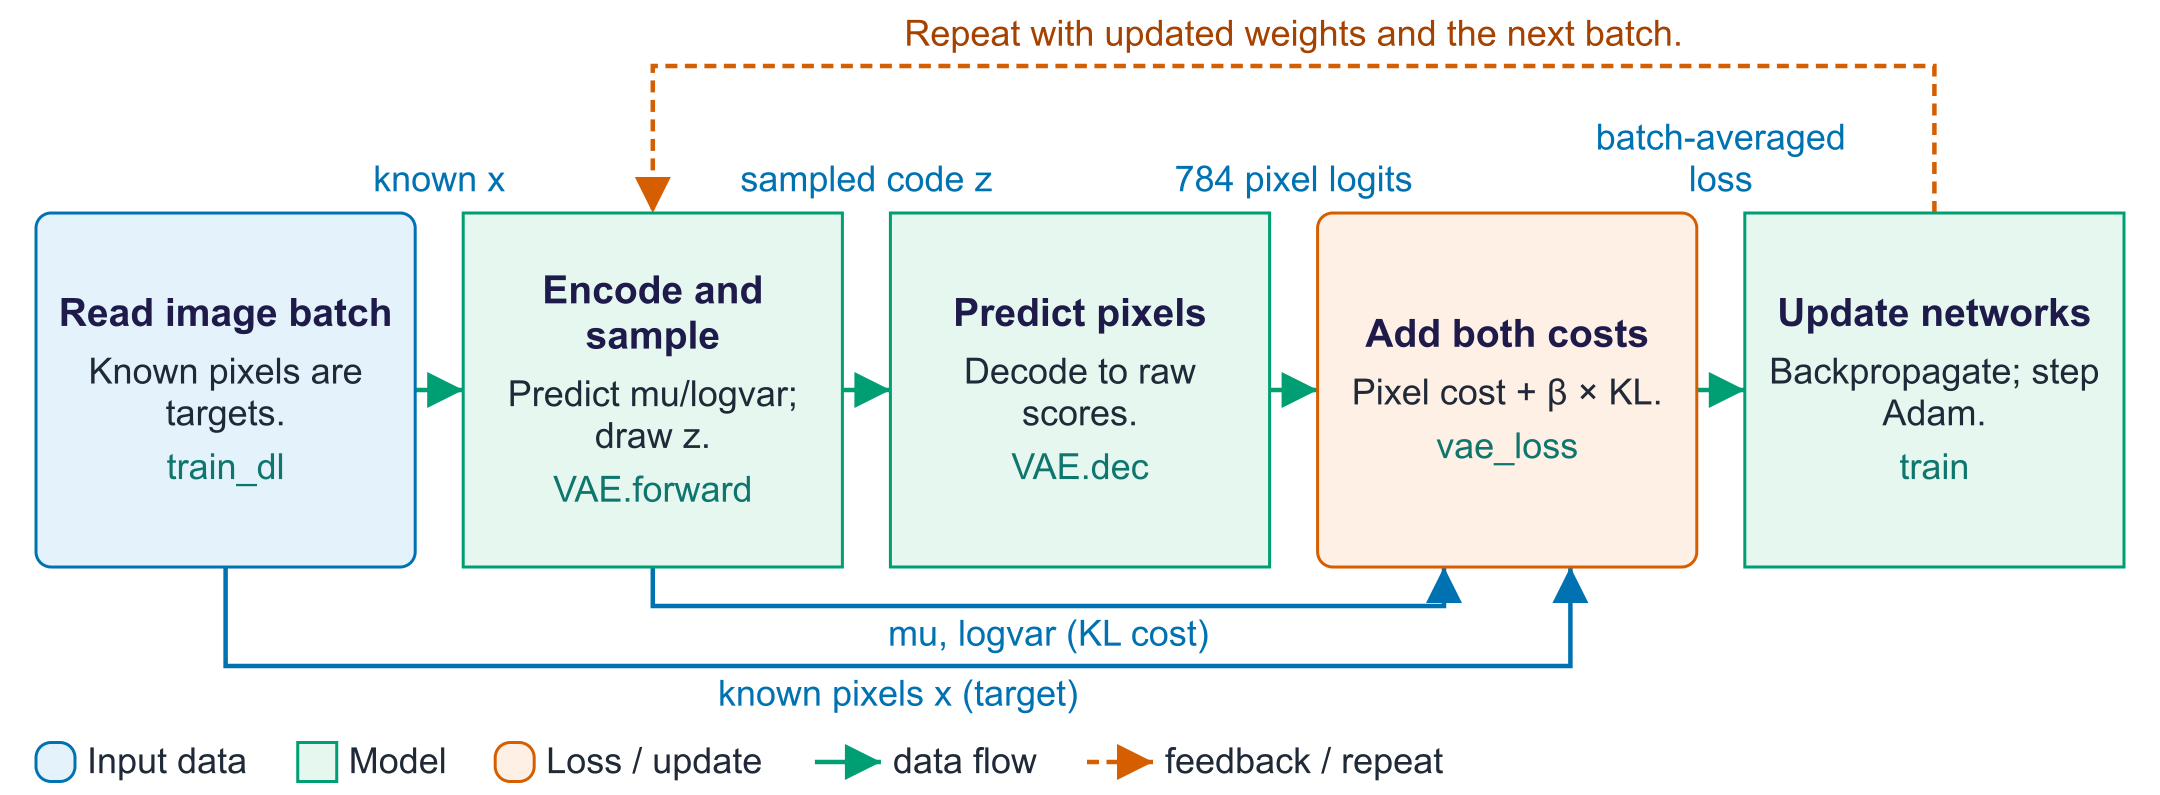

In [ ]:
def vae_loss(logits, x, mu, logvar, beta=1.0):
    rec = F.binary_cross_entropy_with_logits(logits, x.view(-1, 784), reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    n = x.size(0)
    return (rec + beta * kl) / n, rec / n, kl / n


# quick check with a random batch
m = VAE().to(DEVICE)
xb = x_test[:8].to(DEVICE)
logits, mu, logvar = m(xb)
loss, rec, kl = vae_loss(logits, xb, mu, logvar)
print(f"untrained: loss {loss.item():.1f}, reconstruction {rec.item():.1f}, KL {kl.item():.3f}")
assert rec.item() > 400, "An untrained decoder should reconstruct badly (BCE around 540 per image)."

✍️ **Question 1.** Before training, the reconstruction term is about 540 nats per image and the KL is almost 0. Explain both numbers.

**✅ Model answer:**
An untrained decoder outputs logits near 0, i.e. probability ≈ 0.5 for every pixel, so each of the 784 pixels costs about ln 2 ≈ 0.69 nats: 784 × 0.69 ≈ 543. The untrained encoder's heads output values near 0, so μ ≈ 0 and log σ² ≈ 0 (σ ≈ 1): the encoder distribution already equals the prior N(0, I), so KL ≈ 0. Training will lower the reconstruction error and, as the codes start carrying information about each image, the KL will rise.

## Part 2 · Train and monitor both terms

Each batch follows the full training diagram. `zero_grad` clears old
gradients, `backward` computes the current ones, and `step` changes weights.
Plotting or calling `decode` does not train the model.

**Purpose:** Train the two-dimensional model.
**Why now:** Optimiser steps learn both networks.
**Expected observation:** Recorded reconstruction and KL change over epochs.

In [ ]:
def train(model, epochs=EPOCHS, beta=1.0, verbose=True):
    # beta changes the training objective; it is not a sampling-temperature setting.
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = []
    for ep in range(epochs):
        model.train()
        sums, n = np.zeros(3), 0
        for x, _ in train_dl:
            x = x.to(DEVICE)
            logits, mu, logvar = model(x)
            loss, rec, kl = vae_loss(logits, x, mu, logvar, beta)
            opt.zero_grad()
            loss.backward()
            opt.step()
            sums += [loss.item(), rec.item(), kl.item()]
            n += 1
        history.append(sums / n)
        if verbose:
            print(f"epoch {ep + 1:2d}: loss {sums[0] / n:6.1f} | reconstruction {sums[1] / n:6.1f} | KL {sums[2] / n:5.2f}")
    return np.array(history)


vae2 = VAE(zdim=2).to(DEVICE)
hist = train(vae2)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(hist[:, 1], marker="o"); ax[0].set_title("reconstruction (BCE per image)")
ax[1].plot(hist[:, 2], marker="o", color="tab:orange"); ax[1].set_title("KL per image (nats)")
for a in ax:
    a.set_xlabel("epoch")
plt.show()

## Part 3 · Explore the latent space

### 3.1 Where does each digit live?

**Purpose:** Plot test-image encoder means.
**Why now:** A two-dimensional code can be viewed as a map.
**Expected observation:** Digit labels colour the plot; they did not train this VAE.

In [ ]:
vae2.eval()
with torch.no_grad():
    mu_test, _ = vae2.encode(x_test.to(DEVICE))
mu_test = mu_test.cpu().numpy()
plt.figure(figsize=(6.5, 5.5))
sc = plt.scatter(mu_test[:, 0], mu_test[:, 1], c=y_test, cmap="tab10", s=4)
plt.colorbar(sc, ticks=range(10), label="digit")
plt.xlabel("z₁"); plt.ylabel("z₂"); plt.title("Encoder means of 5,000 test digits")
plt.show()

### 3.2 Decode a grid of latent points
We space the grid using the Gaussian's quantiles so that it covers the prior evenly.

**Purpose:** Decode a grid of prior codes.
**Why now:** Generation needs codes and the decoder.
**Expected observation:** A grid of images; inspect recognisable digits and failures.

In [ ]:
from scipy.stats import norm

n = 15
grid = norm.ppf(np.linspace(0.03, 0.97, n))
canvas = np.zeros((28 * n, 28 * n))
for i, zy in enumerate(grid[::-1]):
    for j, zx in enumerate(grid):
        img = vae2.decode(torch.tensor([[zx, zy]], dtype=torch.float32, device=DEVICE))[0].cpu().numpy()
        canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = img
plt.figure(figsize=(7, 7))
plt.imshow(canvas, cmap="gray_r")
plt.axis("off")
plt.title("The learned 2-D latent space")
plt.show()

### 3.3 Interpolation (in a 16-dimensional latent space)
A two-number code is easy to plot but has limited capacity. Train a 16-D
model, then **interpolate** between two test digits. Extra code dimensions
may preserve more detail; judge this from your own reconstructions.
Here `t=0` gives the first code, `t=1` gives the second, and values between
them blend the codes before decoding. The decoder is the same at every step.

**TODO 4:** complete `interpolate(z1, z2, steps)` to return `steps` codes on the straight line from `z1` to `z2`: $z_t = (1-t)\,z_1 + t\,z_2$.

**Purpose:** Train and interpolate a larger code.
**Why now:** Extra latent capacity can preserve more detail.
**Expected observation:** Decoded latent path versus direct pixel blending.

In [ ]:
vae16 = VAE(zdim=16).to(DEVICE)
_ = train(vae16, verbose=False)
vae16.eval()


def interpolate(z1, z2, steps=10):
    ts = torch.linspace(0, 1, steps, device=z1.device).unsqueeze(1)
    return (1 - ts) * z1 + ts * z2


with torch.no_grad():
    mu16, _ = vae16.encode(x_test.to(DEVICE))
a_idx = int((y_test == 1).nonzero()[0])
b_idx = int((y_test == 7).nonzero()[0])
path = interpolate(mu16[a_idx], mu16[b_idx])
plt.figure(figsize=(10, 1.4))
plt.imshow(np.hstack(vae16.decode(path).cpu().numpy()), cmap="gray_r")
plt.axis("off")
plt.title("Interpolating from a 1 to a 7")
plt.show()

# Compare with blending pixels directly
blend = [(1 - t) * x_test[a_idx, 0] + t * x_test[b_idx, 0] for t in np.linspace(0, 1, 10)]
plt.figure(figsize=(10, 1.4))
plt.imshow(np.hstack([b.numpy() for b in blend]), cmap="gray_r")
plt.axis("off")
plt.title("Naive pixel blending (for comparison)")
plt.show()

### 3.4 Generate new digits
Sample codes from the prior and decode them into displayed pixel probabilities.
This generation path bypasses the encoder; it does not reconstruct `x_test`.

**Purpose:** Generate without an input image.
**Why now:** Fresh prior codes bypass the encoder.
**Expected observation:** Displayed pixel probabilities from the decoder.

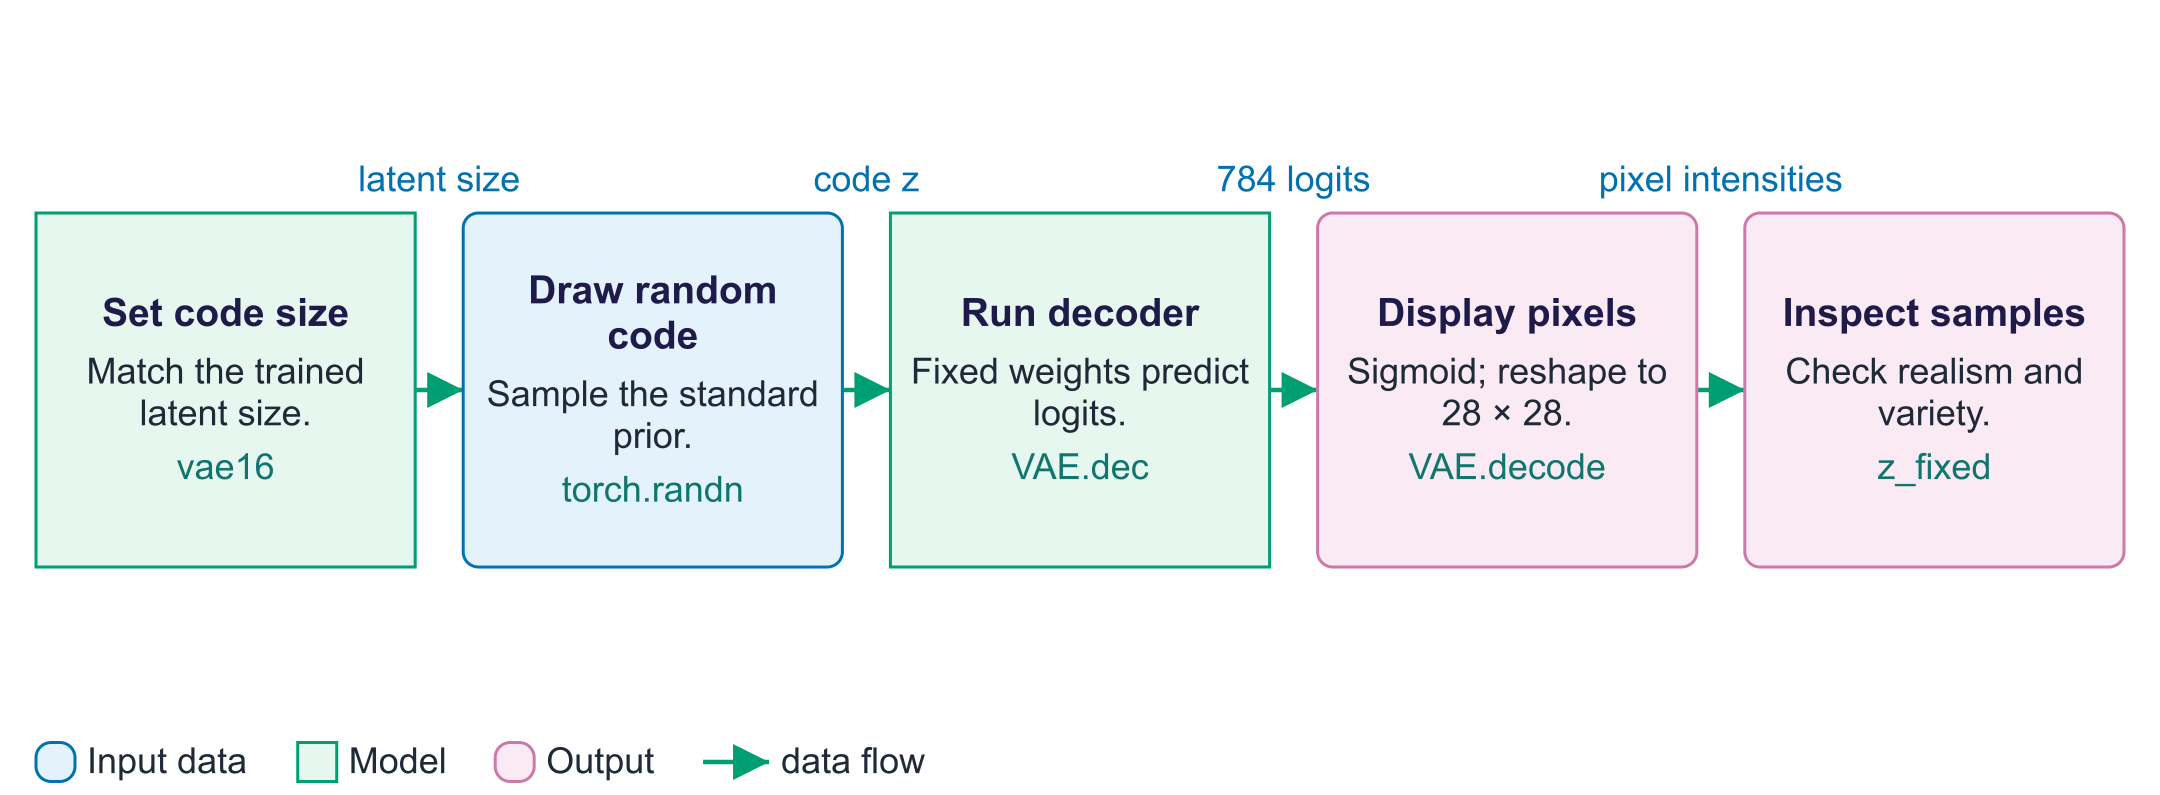

In [ ]:
z = torch.randn(24, 16, device=DEVICE)
plt.figure(figsize=(10, 1.4))
plt.imshow(np.hstack(vae16.decode(z)[:12].cpu().numpy()), cmap="gray_r")
plt.axis("off")
plt.title("New digits sampled from N(0, I)")
plt.show()

✍️ **Question 2.** Compare latent interpolation with pixel blending. What does the difference tell you about the latent space?

**✅ Model answer:**
Pixel blending often overlays the strokes of both digits. Latent interpolation blends their codes, then lets the decoder build each image, so transitions may look more like changing handwriting. Compare the actual middle images; they may still be blurry or malformed. A smooth decoder allows smooth changes, but does not guarantee that every point between two codes is a valid digit. The result is evidence about this trained model's representation, not proof that every straight latent path follows realistic digits.

## Part 4 · The β trade-off

Train three 16-D VAEs with β = 0.1, 1 and 4 (5 epochs each) and compare losses and samples.
**Check a fair comparison:** all three models decode `z_fixed`, the same
random codes. They have different random initial weights, so one run per
beta is illustrative; repeat with several seeds before making a firm claim.

**Purpose:** Compare beta using fixed codes.
**Why now:** Hold code inputs fixed across separately trained models.
**Expected observation:** Costs and sample grids; one run per beta is illustrative.

In [ ]:
results = {}
z_fixed = torch.randn(12, 16, device=DEVICE, generator=torch.Generator(device=DEVICE).manual_seed(2))
for beta in [0.1, 1.0, 4.0]:
    model = VAE(zdim=16).to(DEVICE)
    h = train(model, epochs=1 if SMOKE else 5, beta=beta, verbose=False)
    results[beta] = {"reconstruction": h[-1, 1], "KL": h[-1, 2], "samples": model.decode(z_fixed).cpu().numpy()}
    print(f"beta={beta:>4}: reconstruction {h[-1, 1]:6.1f}   KL {h[-1, 2]:5.2f}")

fig, axes = plt.subplots(3, 1, figsize=(10, 4.2))
for ax, (beta, r) in zip(axes, results.items()):
    ax.imshow(np.hstack(r["samples"]), cmap="gray_r")
    ax.set_title(f"β = {beta}", loc="left")
    ax.axis("off")
plt.tight_layout()
plt.show()

✍️ **Question 3.** Describe the trade-off you observe. Which β would you choose for (a) generating realistic samples, (b) anomaly detection, (c) finding interpretable latent factors? Justify each.

**✅ Model answer:**
Higher beta puts more pressure on code distributions to match the prior, often lowering KL while losing reconstruction detail. Lower beta often preserves more detail but may make fresh prior samples less useful. Report the numbers and pictures you observed; a high beta does not guarantee well-formed samples. (a) For generation, beta = 1 is a useful starting point, then compare sample quality and diversity. (b) For anomaly detection, choose a setting using held-out normal and unusual examples, since reconstruction quality alone is insufficient. (c) For interpretable factors, beta > 1 can encourage simpler codes, but independence or meaning of each coordinate must be tested. There is no single best beta for every purpose.

## Part 5 · Application: anomaly detection with reconstruction error

The VAE has only seen digits. Test whether clothing images (Fashion-MNIST)
receive larger reconstruction errors; an unfamiliar image is not guaranteed
to receive a high score. **AUC** measures how well scores rank unusual
images above normal ones across thresholds: 0.5 is chance ranking, 1 is perfect.

**TODO 5:** complete `recon_error` to return the **per-image** binary cross-entropy (sum over pixels, no averaging over images).

**Purpose:** Evaluate reconstruction as an anomaly score.
**Why now:** Use one score for each held-out image.
**Expected observation:** A ROC AUC and two histograms; clothing is an artificial anomaly.

In [ ]:
from sklearn.metrics import roc_auc_score

fashion = datasets.FashionMNIST("data", train=False, download=True, transform=tf)
x_fashion, _ = next(iter(DataLoader(Subset(fashion, range(2000)), batch_size=2000)))


@torch.no_grad()
def recon_error(model, x):
    # Keep one score per image: this evaluation does not include the KL term.
    x = x.to(DEVICE)
    logits, _, _ = model(x)
    return F.binary_cross_entropy_with_logits(logits, x.view(-1, 784), reduction="none").sum(dim=1).cpu().numpy()


e_digits = recon_error(vae16, x_test[:2000])
e_fashion = recon_error(vae16, x_fashion)
labels = np.r_[np.zeros(len(e_digits)), np.ones(len(e_fashion))]
auc = roc_auc_score(labels, np.r_[e_digits, e_fashion])
plt.figure(figsize=(8, 3.8))
bins = np.linspace(0, np.percentile(np.r_[e_digits, e_fashion], 99), 60)
plt.hist(e_digits, bins=bins, alpha=0.7, label="digits (normal)")
plt.hist(e_fashion, bins=bins, alpha=0.7, label="clothing (anomaly)")
plt.xlabel("reconstruction error"); plt.legend(); plt.title(f"ROC AUC = {auc:.4f}")  # four decimals: 0.9995 is not a perfect 1.000
plt.show()

✍️ **Question 4.** The AUC is very high. Give two reasons why this result may overstate how well the method would work for detecting defects in a real factory.

**✅ Model answer:**
(1) Clothing versus digits is an easy, artificial anomaly: the images differ completely. Real defects (a scratch, a missing component) change only a few pixels and may reconstruct almost perfectly, giving low errors. (2) The anomalies here come from a different dataset with different statistics (brightness, stroke vs. filled shapes), so the model may be detecting "different dataset" rather than "defect". Other valid points: the threshold must be chosen without seeing the test anomalies; class imbalance in real data means precision at low false-positive rates matters more than AUC; normal variation that is under-represented in training (a new supplier, lighting) would be flagged too.

## Part 6 · Extension: a conditional VAE (optional)

Feed the one-hot digit label into both the encoder and the decoder. Then you can **ask** for a digit: sample z and decode it with the label you want.

**Purpose:** Optionally add the digit label.
**Why now:** Conditioning lets generation request a class.
**Expected observation:** Rows asking for different digit labels; success varies with training.

In [ ]:
class CVAE(VAE):
    def __init__(self, zdim=16, hidden=400):
        super().__init__(zdim, hidden)
        self.enc = nn.Sequential(nn.Linear(784 + 10, hidden), nn.ReLU())
        self.dec = nn.Sequential(nn.Linear(zdim + 10, hidden), nn.ReLU(), nn.Linear(hidden, 784))

    def forward(self, x, y):
        y1 = F.one_hot(y, 10).float()
        h = self.enc(torch.cat([x.view(-1, 784), y1], dim=1))
        mu, logvar = self.mu_head(h), self.logvar_head(h)
        z = self.reparameterise(mu, logvar)
        return self.dec(torch.cat([z, y1], dim=1)), mu, logvar

    @torch.no_grad()
    def generate(self, digit, n=10):
        z = torch.randn(n, self.zdim, device=DEVICE)
        y1 = F.one_hot(torch.full((n,), digit, device=DEVICE), 10).float()
        return torch.sigmoid(self.dec(torch.cat([z, y1], dim=1))).view(-1, 28, 28)


cvae = CVAE().to(DEVICE)
opt = torch.optim.Adam(cvae.parameters(), lr=1e-3)
for ep in range(1 if SMOKE else 5):
    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits, mu, logvar = cvae(x, y)
        loss, _, _ = vae_loss(logits, x, mu, logvar)
        opt.zero_grad(); loss.backward(); opt.step()
rows = [np.hstack(cvae.generate(d, 8).cpu().numpy()) for d in range(10)]
plt.figure(figsize=(6, 7.5))
plt.imshow(np.vstack(rows), cmap="gray_r"); plt.axis("off"); plt.title("CVAE: each row asks for one digit")
plt.show()

## Evidence and reflection

| Experiment | Setting | Metric(s) | Observation | One improvement |
|---|---|---|---|---|
| Base VAE | z = 2 / 16, 10 epochs | final reconstruction, KL | | |
| β study | β = 0.1 / 1 / 4 | reconstruction, KL, samples | | |
| Anomaly detection | VAE-16 | ROC AUC | | |

**Before next week:** read Foster (2023) chapter 4 (GANs) and try the PyTorch DCGAN tutorial.

## Week 2: what we learned

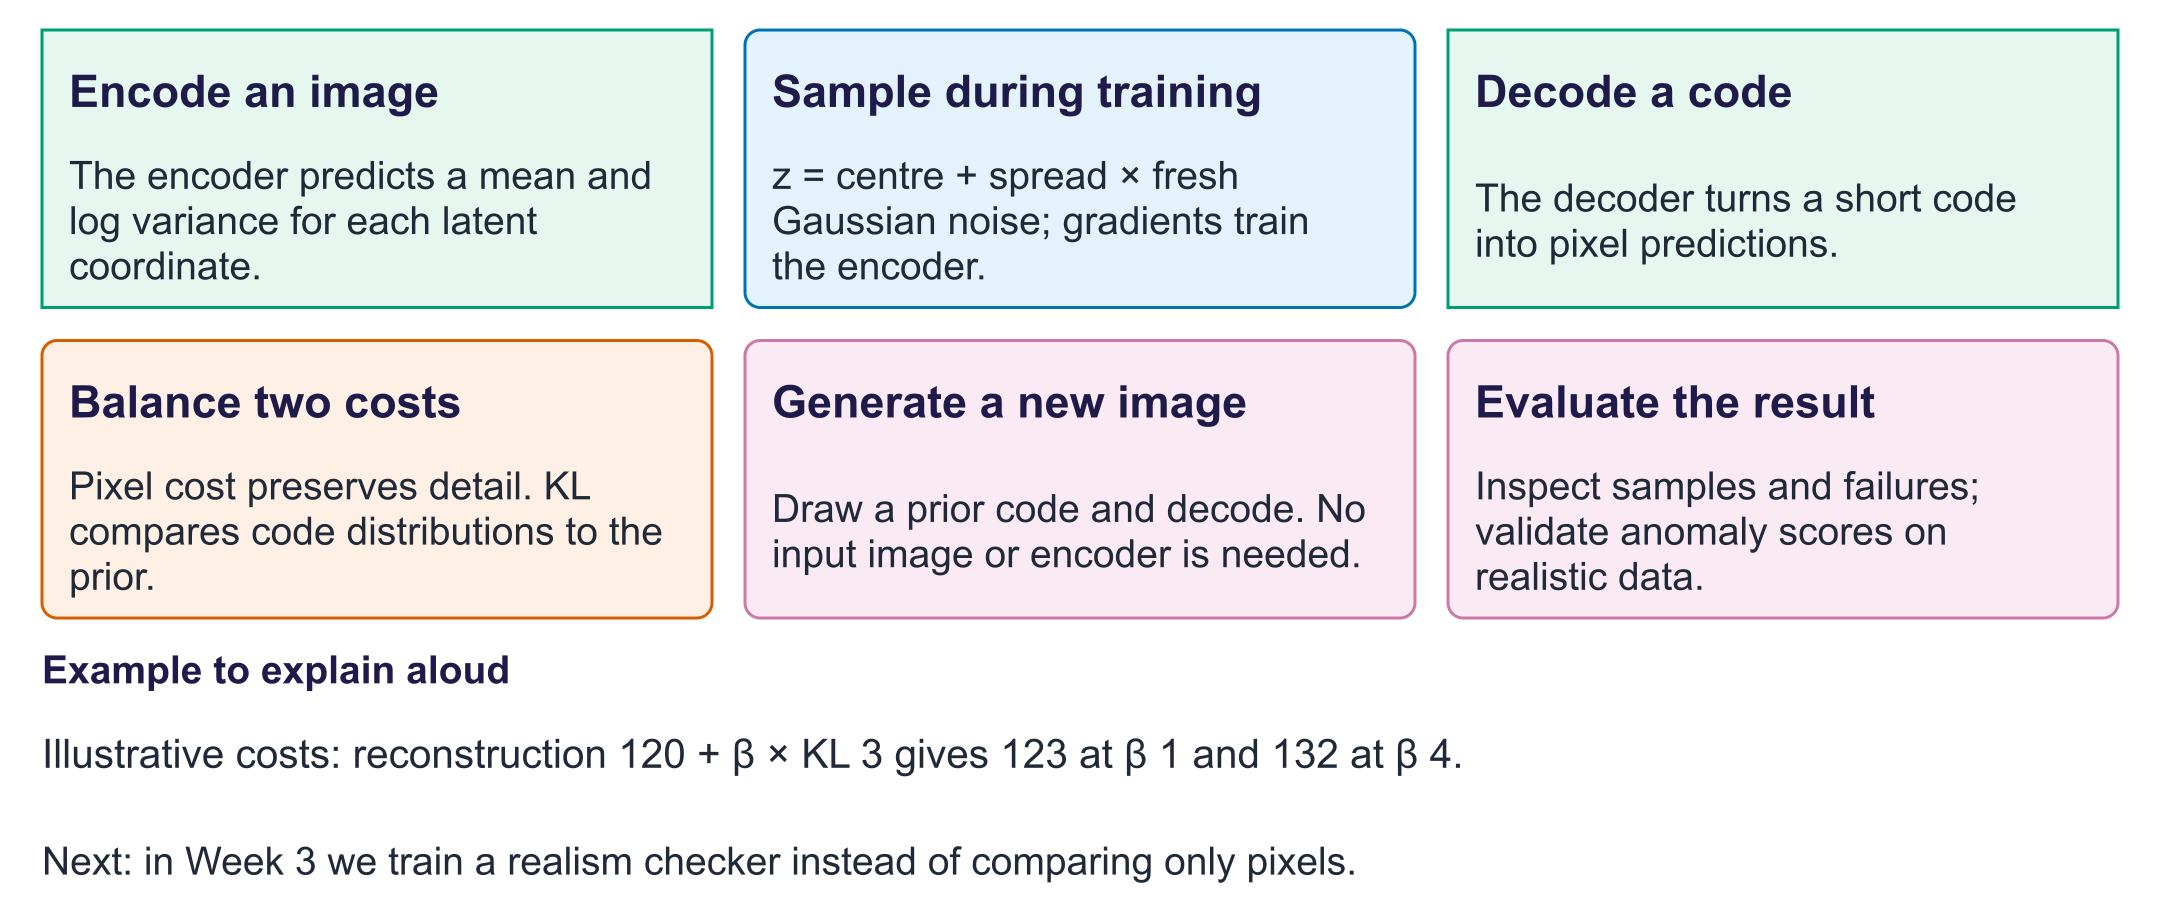

Illustrative costs: reconstruction 120 + β × KL 3 gives 123 at β 1 and 132 at β 4.

**Explain without looking:** If logvar = 0, is the standard deviation 0 or 1?

**Instructor answer:** It is 1: exp(0.5 × 0) = 1. Zero log variance still has spread.